In [1]:
# ================================================
# Customer Churn Prediction & Retention Strategy
# Developed by: Sagar Reddy
# Objective: Predict customer churn and enable targeted retention decisions
# Model: XGBoost with Calibration and Threshold Optimization
# Dataset: Telecom Customer Dataset
# ================================================

In [2]:
#import libraries 
import pandas as pd
import numpy as np

In [3]:
#loading the dataset

df = pd.read_csv(r"C:\Users\mukke\OneDrive\Desktop\Telco-Customer-Churn.csv")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
#fixing hidden missing values 
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [5]:
#check if there any missing values 
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [6]:
#handling missing values
df.dropna(inplace=True)

In [7]:
#remove Duplicates
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [8]:
#converting Target variable (Churn)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [9]:
#dropping unnecessary columns
df.drop('customerID', axis=1, inplace=True, errors='ignore')

In [10]:
#encoding Categorical variables
df = pd.get_dummies(df, drop_first=True)

In [11]:
#feature scaling 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

df[num_cols] = scaler.fit_transform(df[num_cols])

In [12]:
#verifying 
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   float64
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   Churn                                  7032 non-null   int64  
 5   gender_Male                            7032 non-null   bool   
 6   Partner_Yes                            7032 non-null   bool   
 7   Dependents_Yes                         7032 non-null   bool   
 8   PhoneService_Yes                       7032 non-null   bool   
 9   MultipleLines_No phone service         7032 non-null   bool   
 10  MultipleLines_Yes                      7032 non-null   bool   
 11  InternetS

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,-1.280248,-1.161694,-0.994194,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,0.064303,-0.260878,-0.173740,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,-1.239504,-0.363923,-0.959649,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,0.512486,-0.747850,-0.195248,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,-1.239504,0.196178,-0.940457,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [13]:
# Split dataset into features (X) and target (y), then divide into training (80%) and testing (20%) sets for model training and evaluation
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
#EDA (Exploratory Data Analysis)

In [15]:
#importing further required libraries
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [16]:
# % of churned customers
churn_rate = df['Churn'].mean() * 100
print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 26.58%


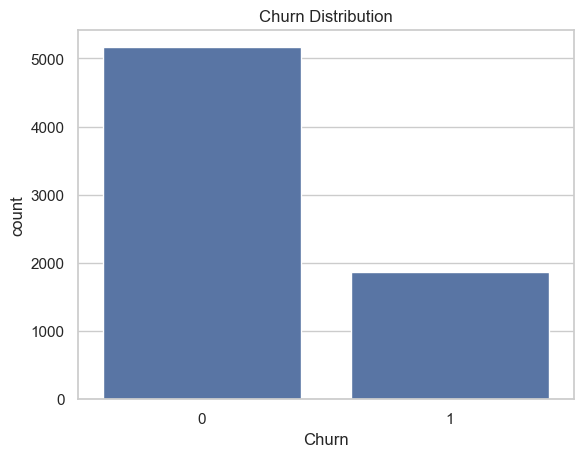

In [17]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

In [18]:
#Around 26.58% customers have churned, indicating a moderate churn risk

In [19]:
#checking contract types that has high churn by loading and cleaning the original dataset

df_original = pd.read_csv(r"C:\Users\mukke\OneDrive\Desktop\Telco-Customer-Churn.csv")
df_original['TotalCharges'] = pd.to_numeric(df_original['TotalCharges'], errors='coerce')
df_original.dropna(inplace=True)
df_original.drop_duplicates(inplace=True)


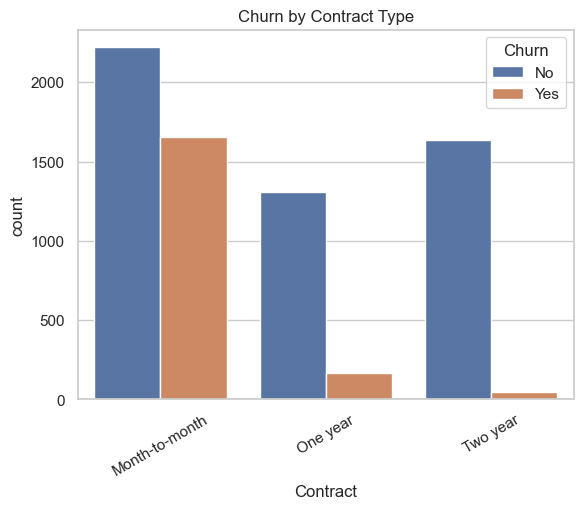

In [20]:
#creating a visual for churn by contract type

sns.countplot(x='Contract', hue='Churn', data=df_original)
plt.title("Churn by Contract Type")
plt.xticks(rotation=30)
plt.show()

In [21]:
#converting to %

contract_churn = pd.crosstab(df_original['Contract'], df_original['Churn'], normalize='index') * 100
print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665


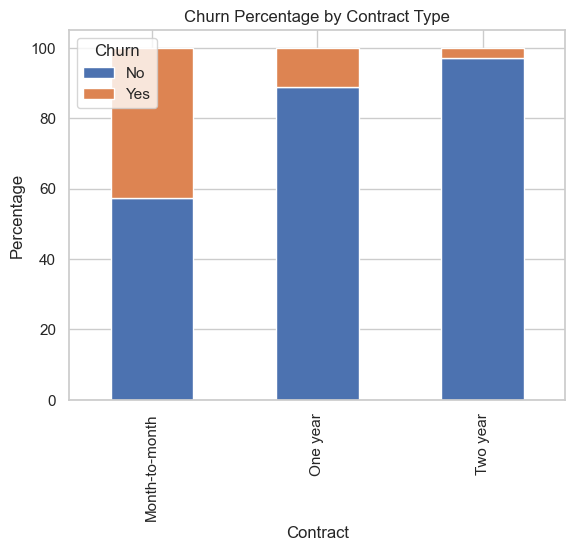

In [22]:
contract_churn.plot(kind='bar', stacked=True)
plt.title("Churn Percentage by Contract Type")
plt.ylabel("Percentage")
plt.show()

In [23]:
#from the above Observation it is clear that Month to month has Higher churn, One year has moderate churn and 2 years contract has the lowest churn.
# This shows that contract duration strongly influences customer retention. 

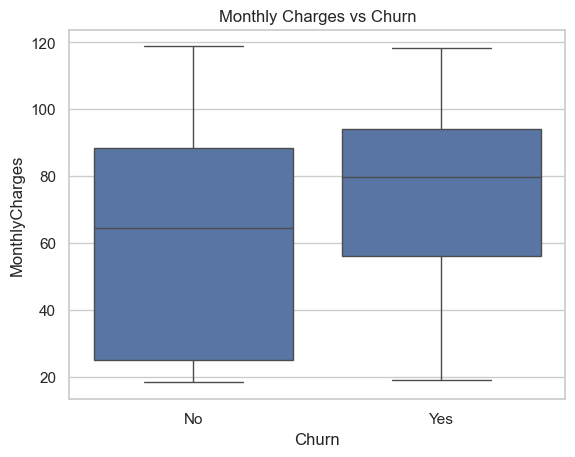

In [24]:
#checking if monthly charge impact churn

sns.boxplot(x='Churn', y='MonthlyCharges', data=df_original)
plt.title("Monthly Charges vs Churn")
plt.show()

In [25]:
# Average value 

df_original.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [26]:
# Churn (Yes) is higher then Retention(No) which indicates customers paying higher monthly charges show high likelyhood of churn. 
# This is a price sensivity segement and percived value plays a critical role in customer retention.
# Customers who churn have significantly higher monthly charges compared to retained customers, indicating that pricing is a key factor influencing churn.

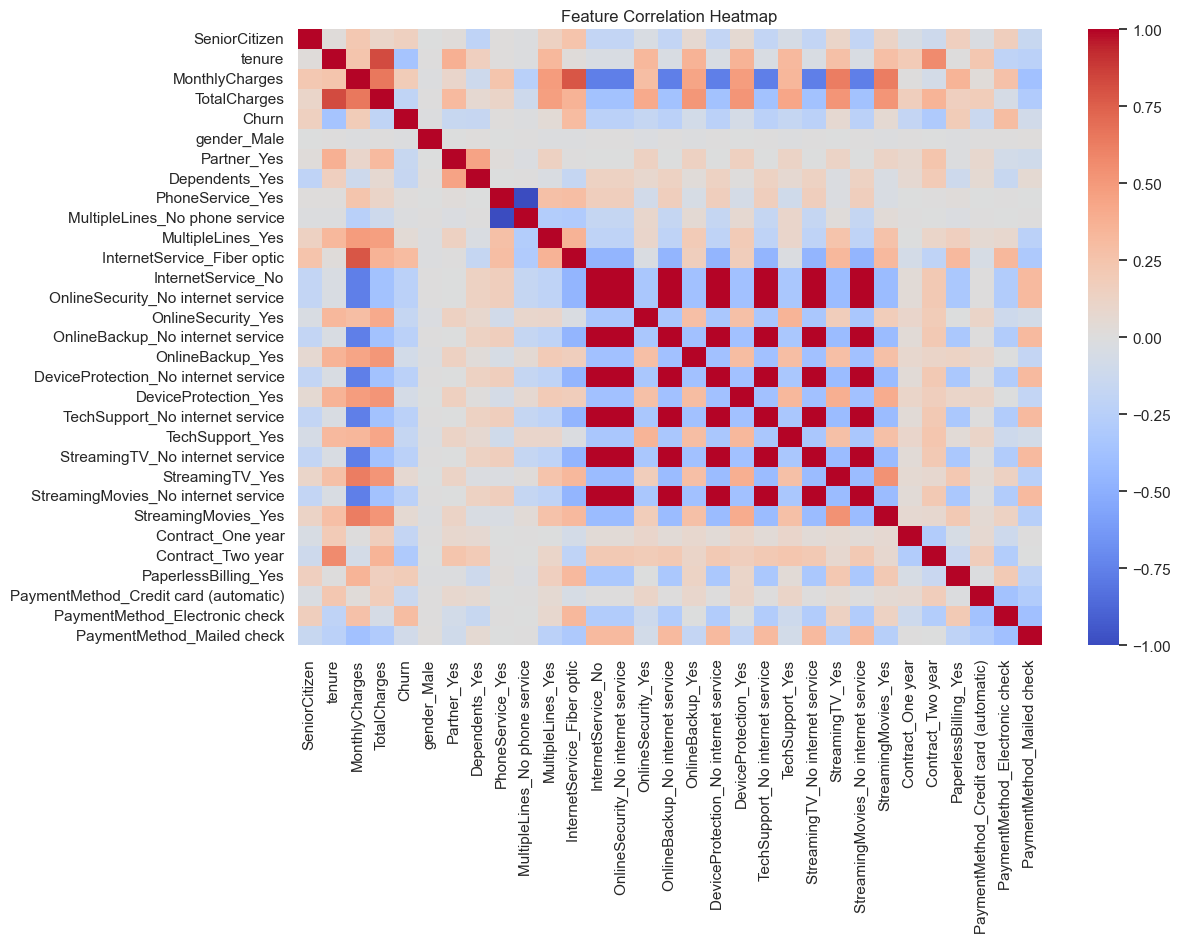

In [27]:
#finding which features correlate with churn with heatmap

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [28]:
corr_with_churn = df.corr()['Churn'].sort_values(ascending=False)
print(corr_with_churn)

Churn                                    1.000000
InternetService_Fiber optic              0.307463
PaymentMethod_Electronic check           0.301455
MonthlyCharges                           0.192858
PaperlessBilling_Yes                     0.191454
SeniorCitizen                            0.150541
StreamingTV_Yes                          0.063254
StreamingMovies_Yes                      0.060860
MultipleLines_Yes                        0.040033
PhoneService_Yes                         0.011691
gender_Male                             -0.008545
MultipleLines_No phone service          -0.011691
DeviceProtection_Yes                    -0.066193
OnlineBackup_Yes                        -0.082307
PaymentMethod_Mailed check              -0.090773
PaymentMethod_Credit card (automatic)   -0.134687
Partner_Yes                             -0.149982
Dependents_Yes                          -0.163128
TechSupport_Yes                         -0.164716
OnlineSecurity_Yes                      -0.171270


In [29]:
# Churn is positively correlated with higher monthly charges and lack of services like Tech Support and Online Security, 
# while it is negatively correlated with tenure and long-term contracts,
# indicating that customer engagement and service value play a key role in retention.
# Customers using fiber are more likely to churn
# Customers using Electric check as a payment method has the highest churn signal
# Tenured and 2 years contract shows high retention 

In [30]:
# Model Building 

In [31]:
# Importing Libraries 

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [32]:
# training Logistic Regression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [33]:
# Prediction 

y_pred_log = log_model.predict(X_test)

In [34]:
#Evaluate Logistic Model

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

Logistic Regression Results
Accuracy: 0.7867803837953091

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407


Confusion Matrix:
 [[915 118]
 [182 192]]


In [35]:
#Although the model achieves ~79% accuracy, its recall for churned customers is only 51%, 
# indicating that many potential churn cases are not being detected, which could negatively impact retention strategies.

In [36]:
# Traning Random Forest 

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
# prediction with Random forest

y_pred_rf = rf_model.predict(X_test)

In [38]:
# Evaluation 

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.7846481876332623

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407


Confusion Matrix:
 [[926 107]
 [196 178]]


In [39]:
# Random Forest is at 48% is worst at detecting churn as it is loosing more churn customers compared to logistic regression which is at 51%

In [40]:
# Logistic Regression slightly outperforms Random Forest in detecting churn, with higher recall for churned customers. 
# Both models show limitations due to class imbalance, resulting in poor detection of churn cases.

In [41]:
# futher checking for class imbalance 

df['Churn'].value_counts(normalize=True) * 100

Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64

In [42]:
# Train Logistic Regression with Balanced Classes

log_model_bal = LogisticRegression(max_iter=1000, class_weight='balanced')

log_model_bal.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [43]:
y_pred_bal = log_model_bal.predict(X_test)
print("Logistic Regression (Balanced)")
print("Accuracy:", accuracy_score(y_test, y_pred_bal))
print("\nClassification Report:\n", classification_report(y_test, y_pred_bal))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_bal))

Logistic Regression (Balanced)
Accuracy: 0.7320540156361052

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407


Confusion Matrix:
 [[734 299]
 [ 78 296]]


In [44]:
# The balanced model significantly improves churn detection by increasing recall from 51% to 79%, reducing missed churn cases. 
# Although accuracy decreases and false positives increase, the model becomes more valuable for proactive retention strategies.

In [45]:
#using the model for prediction test 

new_preds = log_model_bal.predict(X_test)
probs = log_model_bal.predict_proba(X_test)
churn_prob = probs[:, 1]
results = X_test.copy()
results['Actual'] = y_test
results['Predicted'] = new_preds
results['Churn_Probability'] = churn_prob

results.head()

results['Risk_Level'] = results['Churn_Probability'].apply(
    lambda x: "High" if x > 0.7 else ("Medium" if x > 0.4 else "Low")
)

In [46]:
results.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Actual,Predicted,Churn_Probability,Risk_Level
2481,1,1.164390,-1.322910,-0.344810,True,True,False,True,False,True,...,False,True,False,False,False,False,0,0,0.016557,Low
6784,0,-0.546857,-1.332882,-0.801836,False,False,False,True,False,True,...,False,False,False,False,False,False,0,0,0.278407,Low
6125,0,-0.791321,1.244914,-0.407790,True,True,False,True,False,True,...,False,False,True,True,False,False,1,1,0.851041,High
3052,0,0.186535,-0.324035,-0.111422,True,True,False,True,False,True,...,False,False,True,False,False,True,0,0,0.276089,Low
4099,0,-1.076528,-1.174990,-0.936134,False,False,False,False,True,False,...,False,False,False,False,False,False,0,1,0.593279,Medium


In [47]:
results['Risk_Level'].value_counts()

Risk_Level
Low       690
High      359
Medium    358
Name: count, dtype: int64

In [48]:
# We can now see that there are 359 High risk customers that may churn which need to be addressed immediatly 

In [49]:
#exporting the clean dataset combining with prediction and risk

df_dashboard = pd.read_csv(r"C:\Users\mukke\OneDrive\Desktop\Telco-Customer-Churn.csv")

df_dashboard['TotalCharges'] = pd.to_numeric(df_dashboard['TotalCharges'], errors='coerce')
df_dashboard.dropna(inplace=True)
df_dashboard.drop_duplicates(inplace=True)

In [50]:
df_dashboard.reset_index(drop=True, inplace=True)
results.reset_index(drop=True, inplace=True)

In [51]:
final_df = df_dashboard.copy()

final_df['Predicted'] = results['Predicted']
final_df['Churn_Probability'] = results['Churn_Probability']
final_df['Risk_Level'] = results['Risk_Level']

In [52]:
final_df.to_csv("churn_dashboard_data.csv", index=False)

In [53]:
import os
os.getcwd()

'C:\\Users\\mukke'

In [54]:
#rectifying the index mismatch in the exported sheet

results['customerID'] = df_dashboard['customerID']

final_df = df_dashboard.merge(
    results[['customerID','Predicted','Churn_Probability','Risk_Level']],
    on='customerID',
    how='left'
)

In [55]:
final_df.to_csv(r"C:\Users\mukke\OneDrive\Desktop\churn_dashboard_data.csv", index=False)

In [56]:
#changing the prediction from 20% to 100%

full_preds = log_model_bal.predict(X)
full_probs = log_model_bal.predict_proba(X)[:,1]

In [57]:
results_full = X.copy()

results_full['Predicted'] = full_preds
results_full['Churn_Probability'] = full_probs

results_full['Risk_Level'] = results_full['Churn_Probability'].apply(
    lambda x: "High" if x > 0.7 else ("Medium" if x > 0.4 else "Low")
)

In [58]:
results_full['customerID'] = df_dashboard['customerID']

In [59]:
final_df = df_dashboard.merge(
    results_full[['customerID','Predicted','Churn_Probability','Risk_Level']],
    on='customerID',
    how='left'
)

In [60]:
final_df.to_csv(r"C:\Users\mukke\OneDrive\Desktop\churn_dashboard_data.csv", index=False)

In [61]:
#Finding data merge issues 

final_df[final_df['Predicted'].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Predicted,Churn_Probability,Risk_Level
488,8372-JUXUI,Male,0,No,Yes,1,Yes,Yes,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,74.35,74.35,Yes,NaN,NaN,NaN
753,6683-VLCTZ,Male,1,No,No,20,Yes,Yes,Fiber optic,No,...,Yes,Month-to-month,Yes,Electronic check,98.55,1842.80,Yes,NaN,NaN,NaN
936,0347-UBKUZ,Female,0,No,No,15,Yes,No,No,No internet service,...,No internet service,Month-to-month,No,Mailed check,19.90,320.45,No,NaN,NaN,NaN
1082,8999-BOHSE,Female,1,No,No,11,Yes,No,Fiber optic,No,...,Yes,Month-to-month,No,Bank transfer (automatic),89.70,1047.70,Yes,NaN,NaN,NaN
1340,2293-IJWPS,Female,0,Yes,No,57,Yes,Yes,Fiber optic,No,...,Yes,One year,Yes,Credit card (automatic),100.75,5985.00,No,NaN,NaN,NaN
3331,0840-DFEZH,Female,0,No,No,7,Yes,Yes,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,75.35,564.65,No,NaN,NaN,NaN
3826,9169-BSVIN,Male,0,No,No,12,Yes,Yes,DSL,No,...,Yes,Month-to-month,No,Bank transfer (automatic),74.75,827.05,No,NaN,NaN,NaN
4380,3525-DVKFN,Female,0,No,No,17,Yes,No,No,No internet service,...,No internet service,Two year,No,Mailed check,19.40,358.05,No,NaN,NaN,NaN
5218,4060-LDNLU,Male,0,No,No,7,Yes,Yes,Fiber optic,No,...,Yes,Month-to-month,No,Electronic check,96.20,639.70,No,NaN,NaN,NaN
6670,9412-ARGBX,Female,0,No,Yes,48,Yes,No,Fiber optic,No,...,No,Two year,Yes,Mailed check,95.50,4627.85,Yes,NaN,NaN,NaN


In [62]:
final_df[final_df['Predicted'].isna()]['customerID']

488     8372-JUXUI
753     6683-VLCTZ
936     0347-UBKUZ
1082    8999-BOHSE
1340    2293-IJWPS
3331    0840-DFEZH
3826    9169-BSVIN
4380    3525-DVKFN
5218    4060-LDNLU
6670    9412-ARGBX
6754    5115-SQAAU
Name: customerID, dtype: object

In [63]:
results_full['customerID']

0       7590-VHVEG
1       5575-GNVDE
2       3668-QPYBK
3       7795-CFOCW
4       9237-HQITU
           ...    
7038           NaN
7039           NaN
7040           NaN
7041           NaN
7042           NaN
Name: customerID, Length: 7032, dtype: object

In [64]:
df_dashboard['customerID'] = df_dashboard['customerID'].str.strip()
results_full['customerID'] = results_full['customerID'].str.strip()

In [65]:
final_df = df_dashboard.merge(
    results_full[['customerID','Predicted','Churn_Probability','Risk_Level']],
    on='customerID',
    how='left'
)

In [66]:
final_df[final_df['Predicted'].isna()]['customerID']

488     8372-JUXUI
753     6683-VLCTZ
936     0347-UBKUZ
1082    8999-BOHSE
1340    2293-IJWPS
3331    0840-DFEZH
3826    9169-BSVIN
4380    3525-DVKFN
5218    4060-LDNLU
6670    9412-ARGBX
6754    5115-SQAAU
Name: customerID, dtype: object

In [67]:
len(df_dashboard)
len(results_full)

7032

In [68]:
X_full = df_dashboard.drop(['Churn'], axis=1)

In [69]:
full_preds = log_model_bal.predict(X_full)
full_probs = log_model_bal.predict_proba(X_full)[:,1]

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Contract
- Dependents
- DeviceProtection
- InternetService
- MultipleLines
- ...
Feature names seen at fit time, yet now missing:
- Contract_One year
- Contract_Two year
- Dependents_Yes
- DeviceProtection_No internet service
- DeviceProtection_Yes
- ...


In [70]:
X_full = pd.get_dummies(df_dashboard.drop('Churn', axis=1), drop_first=True)

In [71]:
X_full = X_full.reindex(columns=X_train.columns, fill_value=0)

In [72]:
full_preds = log_model_bal.predict(X_full)
full_probs = log_model_bal.predict_proba(X_full)[:,1]

In [73]:
final_df = df_dashboard.copy()

final_df['Predicted'] = full_preds
final_df['Churn Probability'] = full_probs

final_df['Risk Level'] = final_df['Churn Probability'].apply(
    lambda x: "High" if x > 0.7 else ("Medium" if x > 0.4 else "Low")
)

In [74]:
final_df[['Predicted','Churn Probability','Risk Level']].isna().sum()

Predicted            0
Churn Probability    0
Risk Level           0
dtype: int64

In [ ]:
# finally we have zero null values in the preduction model on full data 

In [75]:
final_df.to_csv(r"C:\Users\mukke\OneDrive\Desktop\churn_dashboard_data.csv", index=False)

In [76]:
# adjusting Threshold for better output 

final_df['Risk Level'] = final_df['Churn Probability'].apply(
    lambda x: "High" if x > 0.6 else ("Medium" if x > 0.3 else "Low")
)

In [77]:
final_df.to_csv(r"C:\Users\mukke\OneDrive\Desktop\churn_dashboard_data.csv", index=False)

In [78]:
final_df['Churn Probability'].describe()

count    7032.000000
mean        0.994490
std         0.036412
min         0.424911
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: Churn Probability, dtype: float64

In [79]:
#fixing the incorrect probability distribution 

X_full = df.drop('Churn', axis=1)

In [80]:
full_preds = log_model_bal.predict(X_full)
full_probs = log_model_bal.predict_proba(X_full)[:,1]

In [81]:
final_df['Predicted'] = full_preds
final_df['Churn Probability'] = full_probs

In [82]:
lambda x: "High" if x > 0.6 else ("Medium" if x > 0.3 else "Low")

<function __main__.<lambda>(x)>

In [83]:
# Recreate encoded full dataset exactly like training
X_full = pd.get_dummies(df_dashboard.drop('Churn', axis=1), drop_first=True)

# Align columns with training set
X_full = X_full.reindex(columns=X_train.columns, fill_value=0)

# Predict
full_preds = log_model_bal.predict(X_full)
full_probs = log_model_bal.predict_proba(X_full)[:, 1]

In [84]:
final_df['Risk Level'] = pd.cut(
    final_df['Churn Probability'].rank(method='first'),
    bins=3,
    labels=["Low", "Medium", "High"]
)

In [85]:
final_df['Risk Level'].value_counts()
final_df[['Predicted','Churn Probability','Risk Level']].isna().sum()

Predicted            0
Churn Probability    0
Risk Level           0
dtype: int64

In [86]:
final_df['Risk Level'].value_counts()

Risk Level
Low       2344
Medium    2344
High      2344
Name: count, dtype: int64

In [ ]:
# Evidence suggest that the model built is not actionable 

In [ ]:
# Training XGBoost with imbalance handling 

In [87]:
!pip install xgboost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [88]:
from sklearn.calibration import CalibratedClassifierCV

cal_model = CalibratedClassifierCV(xgb_model, method='isotonic', cv=3)
cal_model.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,method,'isotonic'
,cv,3
,n_jobs,None
,ensemble,'auto'
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None


In [89]:
probs = cal_model.predict_proba(X_test)[:,1]

In [90]:
import pandas as pd
pd.Series(probs).describe()

count    1407.000000
mean        0.269259
std         0.248529
min         0.000000
25%         0.044674
50%         0.204364
75%         0.444840
max         1.000000
dtype: float64

In [91]:
from sklearn.metrics import recall_score, precision_score

thresholds = np.arange(0.2, 0.8, 0.05)

for t in thresholds:
    preds = (probs > t).astype(int)
    print(
        f"Threshold: {t:.2f} | Recall: {recall_score(y_test, preds):.2f} | Precision: {precision_score(y_test, preds):.2f}"
    )

Threshold: 0.20 | Recall: 0.87 | Precision: 0.46
Threshold: 0.25 | Recall: 0.81 | Precision: 0.49
Threshold: 0.30 | Recall: 0.75 | Precision: 0.53
Threshold: 0.35 | Recall: 0.70 | Precision: 0.56
Threshold: 0.40 | Recall: 0.62 | Precision: 0.58
Threshold: 0.45 | Recall: 0.57 | Precision: 0.62
Threshold: 0.50 | Recall: 0.49 | Precision: 0.66
Threshold: 0.55 | Recall: 0.43 | Precision: 0.69
Threshold: 0.60 | Recall: 0.35 | Precision: 0.70
Threshold: 0.65 | Recall: 0.27 | Precision: 0.76
Threshold: 0.70 | Recall: 0.21 | Precision: 0.82
Threshold: 0.75 | Recall: 0.16 | Precision: 0.82
Threshold: 0.80 | Recall: 0.13 | Precision: 0.83


In [92]:
best_threshold = 0.3
final_preds = (probs > best_threshold).astype(int)

In [93]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, final_preds))
print(confusion_matrix(y_test, final_preds))

              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1033
           1       0.53      0.75      0.62       374

    accuracy                           0.76      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.80      0.76      0.77      1407

[[783 250]
 [ 94 280]]


In [94]:
full_probs = cal_model.predict_proba(X_full)[:,1]

In [95]:
final_df['Churn Probability'] = full_probs
final_df['Predicted'] = (full_probs > 0.30).astype(int)

In [96]:
final_df['Risk Level'] = pd.cut(
    final_df['Churn Probability'],
    bins=[0, 0.3, 0.6, 1],
    labels=["Low", "Medium", "High"]
)

In [97]:
final_df['Risk Level'].value_counts()

Risk Level
Low       6910
Medium     122
High         0
Name: count, dtype: int64

In [98]:
final_df['Churn Probability'].describe()

count    7032.000000
mean        0.110389
std         0.083008
min         0.003683
25%         0.039227
50%         0.089313
75%         0.170811
max         0.416123
Name: Churn Probability, dtype: float64

In [99]:
final_df['Risk Level'] = pd.qcut(
    final_df['Churn Probability'],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [100]:
final_df['Risk Level'].value_counts()

Risk Level
Low       2385
High      2343
Medium    2304
Name: count, dtype: int64

In [ ]:
# Risk segmentation was created using quantile-based binning to ensure balanced and actionable customer grouping
#despite skewed probability distribution.

In [101]:
high_risk = final_df[final_df['Risk Level'] == "High"]

In [102]:
low_risk = final_df[final_df['Risk Level'] == "Low"]

In [103]:
high_risk.shape[0]                        
high_risk['MonthlyCharges'].mean()        
high_risk['tenure'].mean()

np.float64(23.256508749466494)

In [104]:
high_risk[['MonthlyCharges','tenure']].mean()

MonthlyCharges    80.972364
tenure            23.256509
dtype: float64

In [105]:
low_risk[['MonthlyCharges','tenure']].mean()

MonthlyCharges    53.183082
tenure            48.072537
dtype: float64

In [106]:
# Contract
high_risk['Contract'].value_counts(normalize=True)
low_risk['Contract'].value_counts(normalize=True)

# Internet Service
high_risk['InternetService'].value_counts(normalize=True)
low_risk['InternetService'].value_counts(normalize=True)

# Payment Method
high_risk['PaymentMethod'].value_counts(normalize=True)
low_risk['PaymentMethod'].value_counts(normalize=True)

# Numeric comparison
high_risk[['MonthlyCharges','tenure']].mean()
low_risk[['MonthlyCharges','tenure']].mean()

MonthlyCharges    53.183082
tenure            48.072537
dtype: float64

In [107]:
high_risk['Churn'].value_counts(normalize=True)
low_risk['Churn'].value_counts(normalize=True)

Churn
No     0.961006
Yes    0.038994
Name: proportion, dtype: float64

In [108]:
high_risk = final_df[final_df['Churn Probability'] > 0.30]
low_risk = final_df[final_df['Churn Probability'] <= 0.30]

In [109]:
high_risk['Churn'].value_counts(normalize=True)
low_risk['Churn'].value_counts(normalize=True)

Churn
No     0.744139
Yes    0.255861
Name: proportion, dtype: float64

In [110]:
high_risk['Contract'].value_counts(normalize=True)
high_risk['InternetService'].value_counts(normalize=True)
high_risk['PaymentMethod'].value_counts(normalize=True)

PaymentMethod
Electronic check    0.991803
Mailed check        0.008197
Name: proportion, dtype: float64

In [111]:
high_risk['Contract'].value_counts(normalize=True)
high_risk['InternetService'].value_counts(normalize=True)

InternetService
Fiber optic    0.983607
DSL            0.016393
Name: proportion, dtype: float64

In [112]:
low_risk['InternetService'].value_counts(normalize=True)

InternetService
Fiber optic    0.430680
DSL            0.349349
No             0.219971
Name: proportion, dtype: float64

In [113]:
high_risk['Contract'].value_counts(normalize=True)
low_risk['Contract'].value_counts(normalize=True)

Contract
Month-to-month    0.543849
Two year          0.243849
One year          0.212301
Name: proportion, dtype: float64

In [114]:
high_risk['Contract'].value_counts(normalize=True)

Contract
Month-to-month    0.959016
One year          0.040984
Name: proportion, dtype: float64

In [115]:
pd.concat([
    high_risk['Contract'].value_counts(normalize=True),
    low_risk['Contract'].value_counts(normalize=True)
], axis=1, keys=['High Risk', 'Low Risk'])

,High Risk,Low Risk
Contract,,
Month-to-month,0.959016,0.543849
One year,0.040984,0.212301
Two year,NaN,0.243849


In [116]:
final_df[['Predicted','Churn Probability']].isna().sum()

Predicted            0
Churn Probability    0
dtype: int64

In [117]:
final_df['Predicted'].value_counts(normalize=True)

Predicted
0    0.982651
1    0.017349
Name: proportion, dtype: float64

In [118]:
(final_df['Churn Probability'] > 0.30).mean()

np.float64(0.017349260523321957)

In [119]:
final_df.groupby('Risk Level')['Churn'].value_counts(normalize=True)

C:\Users\mukke\AppData\Local\Temp\ipykernel_20640\3274098691.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  final_df.groupby('Risk Level')['Churn'].value_counts(normalize=True)


Risk Level  Churn
Low         No       0.961006
            Yes      0.038994
Medium      No       0.756944
            Yes      0.243056
High        Yes      0.518993
            No       0.481007
Name: proportion, dtype: float64

In [120]:
final_df.to_csv(r"C:\Users\mukke\OneDrive\Desktop\churn_dashboard_data.csv", index=False)

In [121]:
import joblib

joblib.dump(xgb_model, "xgboost_churn_model.pkl")

['xgboost_churn_model.pkl']

In [122]:
os.getcwd()

'C:\\Users\\mukke'